# Разработка A/B-тестирования и анализ результатов


## Описание данных

Данные находятся в 3-х таблицах:

- `sessions_project_history.csv` — таблица с историческими данными по сессиям пользователей на период с 2025-08-15 по 2025-09-23.

- `sessions_project_test_part.csv` — таблица с данными за первый день проведения A/B-теста, то есть за 2025-10-14.

- `sessions_project_test.csv` — таблица с данными за весь период проведения A/B-теста, то есть с 2025-10-14 по 2025-11-02.

Поля таблиц `sessions_project_history.csv`, `sessions_project_test.csv`, `sessions_project_test_part.csv`:

- `user_id` — идентификатор пользователя;

- `session_id` — идентификатор сессии в приложении;

- `session_date` — дата сессии;

- `session_start_ts` — дата и время начала сессии;

- `install_date` — дата установки приложения;

- `session_number` — порядковый номер сессии для конкретного пользователя;

- `registration_flag` — является ли пользователь зарегистрированным;

- `page_counter` — количество просмотренных страниц во время сессии;

- `region` — регион пользователя;

- `device` — тип устройства пользователя;

- `test_group` — тестовая группа (в таблице с историческими данными этого столбца нет).


## Задача: рассчитать параметры теста, оценить корректность его проведения и проанализировать результаты эксперимента.

### 1. Работа с историческими данными (EDA)

#### 1.1. Загрузка исторических данных


In [ ]:
# Импортируем библиотеки
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind
from statsmodels.stats.proportion import proportions_ztest

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
from google.colab import files
import io

uploaded = files.upload()

for filename in uploaded.keys():
    sessions_history = pd.read_csv(io.BytesIO(uploaded[filename]))
    break



Saving sessions_project_history.csv to sessions_project_history (1).csv


In [15]:
# Вывод первых 5 строк датафрейма
sessions_history.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android


#### 1.2. Знакомство с данными

- Для каждого уникального пользователя `user_id` рассчитаем количество уникальных сессий `session_id`.

- Выведем все данные из таблицы `sessions_history` для одного пользователя с наибольшим количеством сессий.

- Изучим таблицу данного пользователя, чтобы лучше понять логику формирования каждого столбца данных.



In [19]:
# Рассчитываем количество уникальных сессий для каждого пользователя
sessions_per_user = sessions_history.groupby('user_id')['session_id'].nunique()

# Находим пользователя с максимальным количеством уникальных сессий с помощью idxmax()
max_sessions_user = sessions_per_user.idxmax()
max_sessions_count = sessions_per_user.max()

display(sessions_per_user)
display(f"User ID с максимальным количеством сессий: {max_sessions_user}")
display(f"Количество сессий: {max_sessions_count}")

# Выбираем все записи этого пользователя
user_data = sessions_history[sessions_history['user_id'] == max_sessions_user]
display(user_data)

,session_id
user_id,
00005FB6A13A6FBE,2
0000B15A18D77ED9,3
0000C4E3A4A571A9,2
000293FAF9E67A81,4
00029C5AE889A6C3,2
...,...
FFFCDE7746148710,4
FFFDD413285E753F,3
FFFECBA0F2578AB0,2


'User ID с максимальным количеством сессий: 10E0DEFC1ABDBBE0'

'Количество сессий: 10'

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
115558,10E0DEFC1ABDBBE0,B8F0423BBFFCF5DC,2025-08-14,2025-08-14 13:57:39,2025-08-14,1,0,4,CIS,Android
191751,10E0DEFC1ABDBBE0,87CA2FA549473837,2025-08-15,2025-08-15 16:42:10,2025-08-14,2,0,3,CIS,Android
239370,10E0DEFC1ABDBBE0,4ADD8011DCDCE318,2025-08-16,2025-08-16 19:53:21,2025-08-14,3,0,3,CIS,Android
274629,10E0DEFC1ABDBBE0,DF0FD0E09BF1F3D7,2025-08-17,2025-08-17 15:03:43,2025-08-14,4,0,1,CIS,Android
302501,10E0DEFC1ABDBBE0,3C221774B4DE6885,2025-08-18,2025-08-18 17:29:14,2025-08-14,5,0,4,CIS,Android
325557,10E0DEFC1ABDBBE0,031BD7A67048105B,2025-08-19,2025-08-19 13:23:55,2025-08-14,6,0,2,CIS,Android
345336,10E0DEFC1ABDBBE0,FF4315CF4AD4B100,2025-08-20,2025-08-20 19:31:54,2025-08-14,7,0,2,CIS,Android
377532,10E0DEFC1ABDBBE0,4045FEA0747203B4,2025-08-22,2025-08-22 17:54:13,2025-08-14,8,0,2,CIS,Android
403538,10E0DEFC1ABDBBE0,344B086C421C7F37,2025-08-24,2025-08-24 14:46:13,2025-08-14,9,0,2,CIS,Android
414743,10E0DEFC1ABDBBE0,054F20BA371E4C9D,2025-08-25,2025-08-25 18:36:41,2025-08-14,10,0,3,CIS,Android


#### 1.3. Анализ числа регистраций

Посмотрим, как менялось число регистраций в приложении за время его существования.



In [21]:
# Группируем данные по session_date и user_id, чтобы получить уникальных пользователей на каждый день.
# Берем максимальное значение registration_flag для пользователя за день
daily_users = (sessions_history
               .groupby(['session_date', 'user_id'])
               .agg({'registration_flag': 'max'})
               .reset_index())

# Группируем по session_date и считаем метрики
daily_metrics = (daily_users
                 .groupby('session_date')
                 .agg(unique_users=('user_id', 'nunique'),
                      registered_users=('registration_flag', 'sum'))
                 .reset_index())

display(daily_metrics)

,session_date,unique_users,registered_users
0,2025-08-11,3919,169
1,2025-08-12,6056,336
2,2025-08-13,8489,464
3,2025-08-14,10321,625
4,2025-08-15,14065,840
5,2025-08-16,12205,916
6,2025-08-17,11200,833
7,2025-08-18,10839,860
8,2025-08-19,12118,831
9,2025-08-20,13514,1008


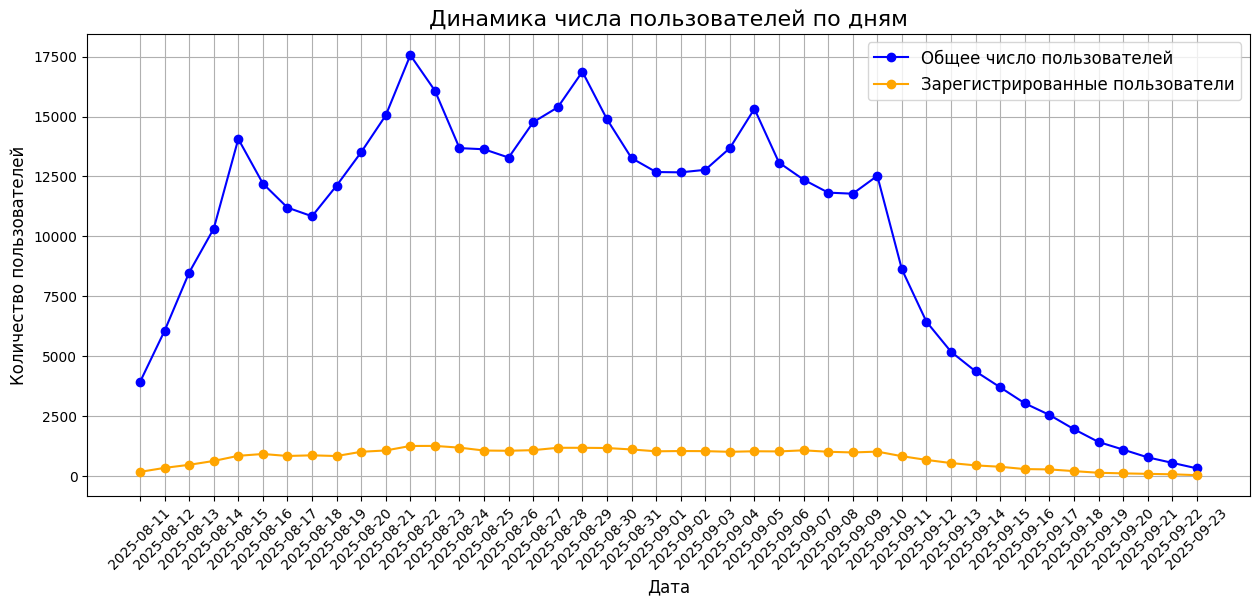

In [22]:
# Построение графиков
plt.figure(figsize=(15, 6))  # Задаем размер графика

# График общего числа пользователей
plt.plot(
    daily_metrics['session_date'],
    daily_metrics['unique_users'],
    label='Общее число пользователей',
    color='blue',
    marker='o')

# График числа зарегистрированных пользователей
plt.plot(
    daily_metrics['session_date'],
    daily_metrics['registered_users'],
    label='Зарегистрированные пользователи',
    color='orange',
    marker='o')

# Настройка графика
plt.title('Динамика числа пользователей по дням', fontsize=16)  # Заголовок
plt.xlabel('Дата', fontsize=12)  # Подпись оси X
plt.ylabel('Количество пользователей', fontsize=12)  # Подпись оси Y
plt.xticks(rotation=45)  # Поворот меток по оси X
plt.legend(fontsize=12)  # Легенда
plt.grid(True)  # Сетка

# Отображение графика
plt.show()

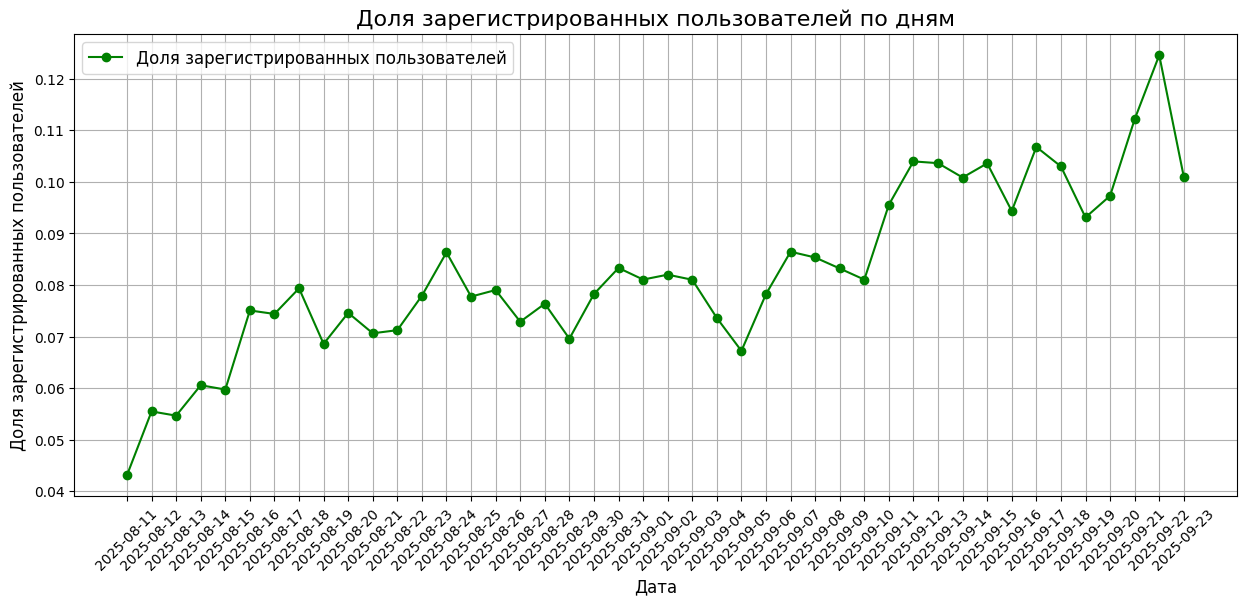

In [23]:
# Рассчитываем долю зарегистрированных пользователей
daily_metrics['registration_ratio'] = daily_metrics['registered_users'] / daily_metrics['unique_users']

# Построение графика
plt.figure(figsize=(15, 6))  # Задаем размер графика

# Линейный график доли зарегистрированных пользователей
plt.plot(
    daily_metrics['session_date'],
    daily_metrics['registration_ratio'],
    label='Доля зарегистрированных пользователей',
    color='green',
    marker='o')

# Настройка графика
plt.title('Доля зарегистрированных пользователей по дням', fontsize=16)  # Заголовок
plt.xlabel('Дата', fontsize=12)  # Подпись оси X
plt.ylabel('Доля зарегистрированных пользователей', fontsize=12)  # Подпись оси Y
plt.xticks(rotation=45)  # Поворот меток по оси X
plt.legend(fontsize=12)  # Легенда
plt.grid(True)  # Сетка

# Отображение графика
plt.show()

In [25]:

# ВЫВОДЫ ПО АНАЛИЗУ УНИКАЛЬНЫХ ПОЛЬЗОВАТЕЛЕЙ И РЕГИСТРАЦИЙ (для меня, в работу не включать)

print("=" * 80)
print("АНАЛИЗ ДИНАМИКИ УНИКАЛЬНЫХ ПОЛЬЗОВАТЕЛЕЙ И РЕГИСТРАЦИЙ")
print("=" * 80)

# 1. ОБЩАЯ ДИНАМИКА
print("\n1. ОБЩАЯ ДИНАМИКА ЗА ПЕРИОД:")
print("-" * 40)

total_days = len(daily_metrics)
total_unique_users = daily_metrics['unique_users'].sum()
total_registrations = daily_metrics['registered_users'].sum()
overall_conversion = total_registrations / total_unique_users * 100

print(f"• Анализируемый период: {total_days} дней (11.08.2025 - 23.09.2025)")
print(f"• Всего уникальных пользователей: {total_unique_users:,}")
print(f"• Всего регистраций: {total_registrations:,}")
print(f"• Общая конверсия в регистрацию: {overall_conversion:.1f}%")

# 2. ПИКОВЫЕ ДНИ
print("\n2. ПИКОВЫЕ ЗНАЧЕНИЯ:")
print("-" * 40)

max_users_day = daily_metrics.loc[daily_metrics['unique_users'].idxmax()]
max_reg_day = daily_metrics.loc[daily_metrics['registered_users'].idxmax()]
max_conversion_day = daily_metrics.assign(
    conversion=lambda x: x['registered_users'] / x['unique_users'] * 100
).loc[lambda x: x['conversion'].idxmax()]

print(f"• Максимум уникальных пользователей:")
print(f"  Дата: {max_users_day['session_date']} - {max_users_day['unique_users']:,} пользователей")

print(f"• Максимум регистраций:")
print(f"  Дата: {max_reg_day['session_date']} - {max_reg_day['registered_users']:,} регистраций")

print(f"• Максимальная конверсия в регистрацию:")
print(f"  Дата: {max_conversion_day['session_date']} - {max_conversion_day['registered_users']/max_conversion_day['unique_users']*100:.1f}%")

# 3. ТРЕНДЫ И СЕЗОННОСТЬ
print("\n3. КЛЮЧЕВЫЕ ТРЕНДЫ:")
print("-" * 40)

# Разделяем на периоды роста и спада
august_data = daily_metrics[daily_metrics['session_date'] <= '2025-08-31']
september_data = daily_metrics[daily_metrics['session_date'] > '2025-08-31']

aug_avg_users = august_data['unique_users'].mean()
sep_avg_users = september_data['unique_users'].mean()
change_pct = (sep_avg_users - aug_avg_users) / aug_avg_users * 100

print(f"• Август 2025: активный рост аудитории")
print(f"  Среднее значение: {aug_avg_users:.0f} пользователей в день")
print(f"• Сентябрь 2025: резкое снижение трафика")
print(f"  Среднее значение: {sep_avg_users:.0f} пользователей в день")
print(f"• Изменение: снижение на {abs(change_pct):.1f}%")

# 4. КОНВЕРСИЯ ПО ПЕРИОДАМ
print("\n4. АНАЛИЗ КОНВЕРСИИ:")
print("-" * 40)

aug_conversion = august_data['registered_users'].sum() / august_data['unique_users'].sum() * 100
sep_conversion = september_data['registered_users'].sum() / september_data['unique_users'].sum() * 100

print(f"• Конверсия в августе: {aug_conversion:.1f}%")
print(f"• Конверсия в сентябре: {sep_conversion:.1f}%")

if sep_conversion > aug_conversion:
    print(f"• Тренд: конверсия выросла на {sep_conversion - aug_conversion:.1f}%")
else:
    print(f"• Тренд: конверсия снизилась на {aug_conversion - sep_conversion:.1f}%")

АНАЛИЗ ДИНАМИКИ УНИКАЛЬНЫХ ПОЛЬЗОВАТЕЛЕЙ И РЕГИСТРАЦИЙ

1. ОБЩАЯ ДИНАМИКА ЗА ПЕРИОД:
----------------------------------------
• Анализируемый период: 44 дней (11.08.2025 - 23.09.2025)
• Всего уникальных пользователей: 435,924
• Всего регистраций: 33,708
• Общая конверсия в регистрацию: 7.7%

2. ПИКОВЫЕ ЗНАЧЕНИЯ:
----------------------------------------
• Максимум уникальных пользователей:
  Дата: 2025-08-22 - 17,563 пользователей
• Максимум регистраций:
  Дата: 2025-08-23 - 1,253 регистраций
• Максимальная конверсия в регистрацию:
  Дата: 2025-09-22 - 12.5%

3. КЛЮЧЕВЫЕ ТРЕНДЫ:
----------------------------------------
• Август 2025: активный рост аудитории
  Среднее значение: 12724 пользователей в день
• Сентябрь 2025: резкое снижение трафика
  Среднее значение: 7335 пользователей в день
• Изменение: снижение на 42.4%

4. АНАЛИЗ КОНВЕРСИИ:
----------------------------------------
• Конверсия в августе: 7.3%
• Конверсия в сентябре: 8.5%
• Тренд: конверсия выросла на 1.2%


##### Основные результаты:

Пиковая активность пришлась на 22 августа 2025 года (17563 уникальных пользователя)

Максимум регистраций зафиксирован 23 августа 2025 года (1253 регистрации)

Наивысшая конверсия достигнута 22 сентября 2025 года (12.5% при среднем значении 7.7%)

Ключевые тренды:

Август показал интенсивный рост аудитории со средним значением 12724 пользователей в день

Сентябрь ознаменовался резким спадом трафика на 42.4% до средних 7335 пользователей

Парадоксально, но конверсия выросла с 7.3% в августе до 8.5% в сентябре (+1.2%)



#### 1.4. Анализ числа просмотренных страниц

Проанализируем число просмотренных страниц в приложении. Чем больше страниц просмотрено, тем сильнее пользователь увлечён контентом, а значит, выше шансы на то, что он зарегистрируется и оплатит подписку.



In [26]:
# Группируем данные по количеству просмотренных страниц (page_counter) и считаем количество сессий (session_count )
sessions_by_page_views = (sessions_history.groupby('page_counter')['session_id'].nunique().reset_index())

# Переименовываем столбцы для удобства
sessions_by_page_views.columns = ['page_counter', 'session_count']

# Сортируем данные по возрастанию количества просмотренных страниц
sessions_by_page_views = sessions_by_page_views.sort_values(by='page_counter').reset_index(drop=True)

# Выводим результат
display(sessions_by_page_views)

,page_counter,session_count
0,1,29160
1,2,105536
2,3,166690
3,4,105569
4,5,26288
5,6,2589
6,7,92


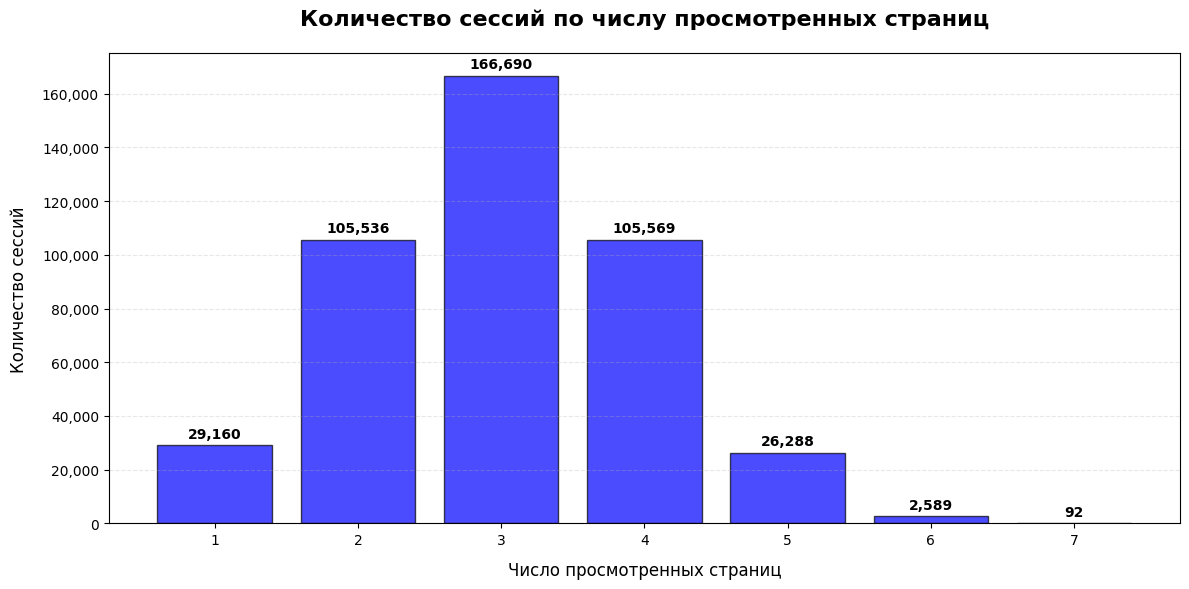

In [28]:
# Построение столбчатой диаграммы
plt.figure(figsize=(12, 6))  # Задаем размер графика

# Столбчатая диаграмма с синим цветом
bars = plt.bar(
    sessions_by_page_views['page_counter'],
    sessions_by_page_views['session_count'],
    color='blue',  # Изменено на синий
    edgecolor='black',
    alpha=0.7)  # Немного прозрачности для лучшего восприятия

# Добавляем значения на столбцы
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,  # X-позиция по центру столбца
        height + max(sessions_by_page_views['session_count']) * 0.01,  # Y-позиция немного выше столбца
        f'{int(height):,}',  # Форматируем число с разделителями тысяч
        ha='center',  # Горизонтальное выравнивание по центру
        va='bottom',  # Вертикальное выравнивание снизу
        fontsize=10,
        fontweight='bold')

# Настройка графика
plt.title('Количество сессий по числу просмотренных страниц', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Число просмотренных страниц', fontsize=12, labelpad=10)
plt.ylabel('Количество сессий', fontsize=12, labelpad=10)
plt.xticks(rotation=0)

# Улучшаем читаемость оси Y
plt.ticklabel_format(style='plain', axis='y')  # Отключаем научную нотацию
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))  # Форматируем с разделителями

# Добавляем легкую сетку для удобства чтения
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Автоматически настраиваем отступы
plt.tight_layout()

# Отображение графика
plt.show()

#### 1.5. Доля пользователей, просмотревших более четырёх страниц

Рассмотрим данную прокси-метрику, так как команда продукта считает, что сессии, в рамках которых пользователь просмотрел 4 и более страниц, говорят об удовлетворённости контентом и алгоритмами рекомендаций.



In [29]:
# Создание столбца good_session
sessions_history['good_session'] = (sessions_history['page_counter'] >= 4).astype(int)

# Группировка данных по дням и расчет доли успешных сессий
daily_good_sessions = (sessions_history.groupby('session_date').agg(total_sessions=('session_id', 'nunique'),
                                                                    good_sessions=('good_session', 'sum')).reset_index())

# Добавляем столбец с долей успешных сессий для построения графика
daily_good_sessions['good_session_ratio'] = daily_good_sessions['good_sessions'] / daily_good_sessions['total_sessions']

display(daily_good_sessions)

,session_date,total_sessions,good_sessions,good_session_ratio
0,2025-08-11,3919,1226,0.312835
1,2025-08-12,6056,1829,0.302015
2,2025-08-13,8489,2604,0.306750
3,2025-08-14,10321,3262,0.316055
4,2025-08-15,14065,4289,0.304941
5,2025-08-16,12205,3737,0.306186
6,2025-08-17,11200,3557,0.317589
7,2025-08-18,10839,3366,0.310545
8,2025-08-19,12118,3791,0.312840
9,2025-08-20,13514,4148,0.306941


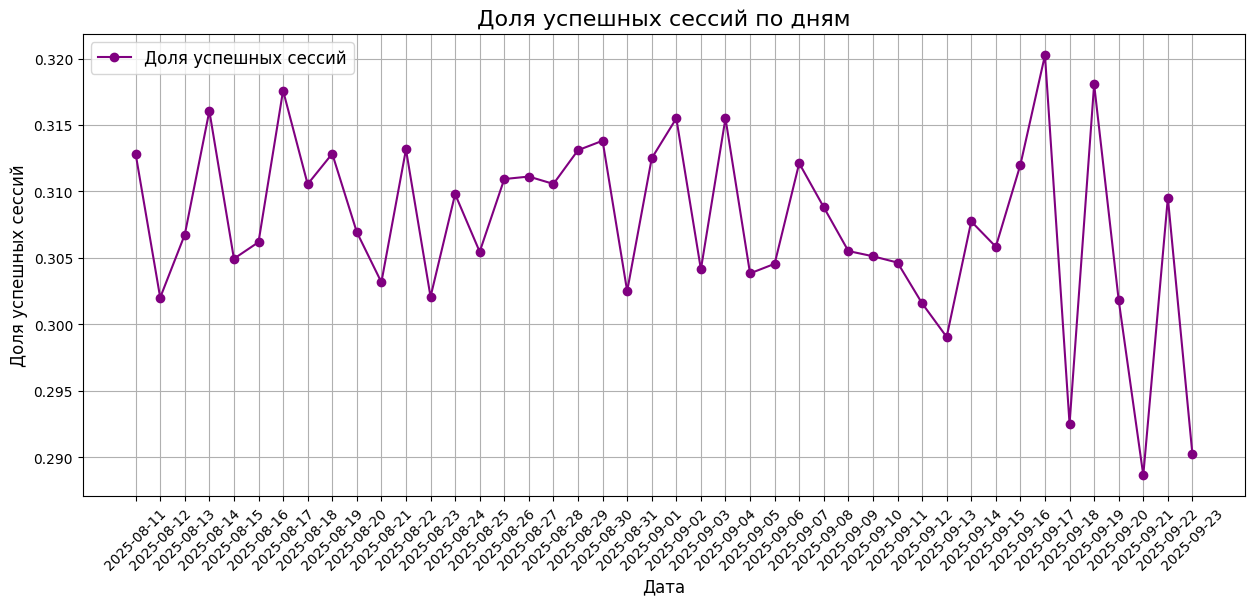

In [40]:
# Построение графика
plt.figure(figsize=(15, 6))  # Задаем размер графика

# Линейный график доли успешных сессий
plt.plot(
    daily_good_sessions['session_date'],
    daily_good_sessions['good_session_ratio'],
    label='Доля успешных сессий',
    color='purple',
    marker='o')

# Настройка графика
plt.title('Доля успешных сессий по дням', fontsize=16)  # Заголовок
plt.xlabel('Дата', fontsize=12)  # Подпись оси X
plt.ylabel('Доля успешных сессий', fontsize=12)  # Подпись оси Y
plt.xticks(rotation=45)  # Поворот меток по оси X
plt.legend(fontsize=12)  # Легенда
plt.grid(True)  # Сетка

# Отображение графика
plt.show()




- В конце периода, когда снизилось число сессий, доля успешных сессий стала более вариативной из-за меньшего количества наблюдений.


### 2. Подготовка к тесту


#### 2.1. Расчёт размера выборки

Установим в коде ниже следующие параметры:

- Уровень значимости — 0.05.

- Вероятность ошибки второго рода — 0.2.

- Мощность теста.

- Минимальный детектируемый эффект — 3%.

При расчёте размера выборки мы будем использовать метод `solve_power()` из класса `power.NormalIndPower` модуля `statsmodels.stats`.



In [42]:
from statsmodels.stats.power import NormalIndPower

# Задаём параметры
alpha = 0.05  # Уровень значимости
beta = 0.2    # Вероятность ошибки второго рода (1 - мощность)
power = 1 - beta  # Мощность теста. Это важный аспект статистического анализа, который помогает оценить вероятность обнаружения реального эффекта.
# Преимущества такого подхода:
# Позволяет осознанно выбирать размер выборки для теста.
# Помогает сбалансировать риск ложных отрицательных результатов.
# Улучшает интерпретацию результатов A/B-тестирования.
mde = 0.03    # Минимальный детектируемый эффект (MDE)

# Инициализируем класс NormalIndPower
power_analysis = NormalIndPower()

# Рассчитываем размер выборки
sample_size = power_analysis.solve_power(
    effect_size=mde,
    power=power,
    alpha=alpha,
    ratio=1  # Равномерное распределение выборок между группами
)

display(f"Необходимый размер выборки для каждой группы: {int(sample_size)}")

'Необходимый размер выборки для каждой группы: 17441'

#### 2.1. Расчёт длительности A/B-теста

Используя данные о количестве пользователей в каждой выборке и среднем количестве пользователей приложения, рассчитаем длительность теста, разделив одно на другое.



In [43]:
from math import ceil

# Среднее количество пользователей приложения в день по историческим данным
avg_daily_users = daily_metrics['unique_users'].mean()

# Рассчитываем длительность теста в днях как отношение размера выборки к среднему числу пользователей
test_duration = ceil(sample_size*2 / avg_daily_users)

display(f"Рассчитанная длительность A/B-теста при текущем уровне трафика в {int(avg_daily_users)} пользователей в день составит {test_duration} дней")

'Рассчитанная длительность A/B-теста при текущем уровне трафика в 9907 пользователей в день составит 4 дней'

4 дня это допустимый минимальный срок, однако для повышения надёжности результатов теста желательно провести его дольше — например, на 7 или даже 14 дней, чтобы сгладить возможные колебания в поведении пользователей по дням недели и собрать больше данных для анализа.    
    
Так же следует учитывать, что в последние дни было снижение активности пользователей, поэтому среднее за весь период не будет однозначно характеризовать размер активной аудитории.    



### 3. Мониторинг А/В-теста

#### 3.1. Проверка распределения пользователей

A/B-тест успешно запущен, и уже доступны данные за первые три дня. Убедимся, что на этом этапе всё идёт хорошо: пользователи разделены правильным образом, а интересующие вас метрики корректно считаются.

- Считаем и сохраним в датафрейм `sessions_test_part` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test_part.csv`.

- Рассчитаем количество уникальных пользователей в каждой из экспериментальных групп для одного дня наблюдения.

- Рассчитаем и выведем процентную разницу в количестве пользователей в группах A и B.

Для расчёта процентной разницы воспользуемся формулой:
$$P = 100 \cdot  \frac{|A − B|}{A}$$

In [44]:
uploaded = files.upload()

for filename in uploaded.keys():
    sessions_test_part  = pd.read_csv(io.BytesIO(uploaded[filename]))
    break

Saving sessions_project_test_part.csv to sessions_project_test_part.csv


In [45]:
# Группируем данные по test_group и считаем количество уникальных user_id
unique_users_per_group = (sessions_test_part.groupby('test_group')['user_id'].nunique().reset_index())

# Переименовываем столбцы для удобства
unique_users_per_group.columns = ['test_group', 'unique_users']

# Выводим результат
display(unique_users_per_group)

,test_group,unique_users
0,A,1477
1,B,1466


In [46]:
# Извлекаем количество уникальных пользователей для групп A и B
users_A = unique_users_per_group.loc[unique_users_per_group['test_group'] == 'A', 'unique_users'].values[0]
users_B = unique_users_per_group.loc[unique_users_per_group['test_group'] == 'B', 'unique_users'].values[0]

# Рассчитываем процентную разницу
percentage_difference = 100 * abs(users_A - users_B) / users_A

# Выводим результат
display(f"Процентная разница в количестве пользователей между группами A и B: {percentage_difference:.2f}%")

'Процентная разница в количестве пользователей между группами A и B: 0.74%'

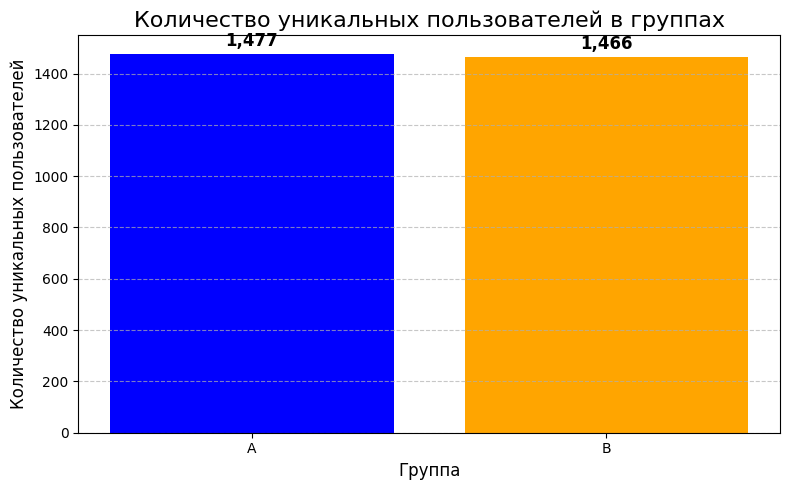

In [48]:
import matplotlib.pyplot as plt

# Построение столбчатой диаграммы
plt.figure(figsize=(8, 5)) # Задаем размер графика

# Столбчатая диаграмма
bars = plt.bar(unique_users_per_group['test_group'],
               unique_users_per_group['unique_users'],
               color=['blue', 'orange'])

# Добавляем значения на столбцы
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2,  # X-позиция по центру столбца
             height + max(unique_users_per_group['unique_users']) * 0.01,  # Y-позиция немного выше
             f'{int(height):,}',  # Форматируем с разделителями тысяч
             ha='center',  # Горизонтальное выравнивание по центру
             va='bottom',  # Вертикальное выравнивание снизу
             fontsize=12,
             fontweight='bold')

# Заголовок графика
plt.title('Количество уникальных пользователей в группах', fontsize=16)

# Подписи осей
plt.xlabel('Группа', fontsize=12)
plt.ylabel('Количество уникальных пользователей', fontsize=12)

# Сетка
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Отображение графика
plt.tight_layout()
plt.show()

Эта проверка важна по нескольким причинам:
    
- Правильность разделения пользователей: Чтобы результат A/B-теста был корректным, важно убедиться, что группы A и B были случайным образом разделены, а не случайным образом или по какому-либо смещённому принципу. Если группы не были равномерно разделены, это может привести к ошибочным выводам, так как различия в поведении пользователей могут быть вызваны не тестируемым фактором, а изначальной неоднородностью групп.
- Корректность расчёта метрик: Мы проверяем, что метрики, такие как количество уникальных пользователей, корректно считаются для каждой из групп. Это важно, потому что любые ошибки в учёте пользователей могут исказить результаты теста и привести к неверным выводам о влиянии изменений на поведение пользователей.
- Обнаружение аномалий: Если процентная разница в количестве пользователей между группами слишком велика, это может свидетельствовать о проблемах с разделением пользователей, таких как технические ошибки или неправильное распределение. Проверка позволяет выявить такие аномалии на ранних стадиях теста и скорректировать процесс.
- Убедительность результатов: Важно, чтобы тест был честным и справедливым. Если группа A имеет значительное преимущество по численности, то результаты могут быть искажены. Это проверка помогает удостовериться, что эксперимент был проведён корректно, и что его результаты можно использовать для объективных выводов.



#### 3.2. Проверка пересечений пользователей
Помимо проверки равенства количества пользователей в группах полезно убедиться в том, что группы независимы. Для этого нужно убедиться, что никто из пользователей случайно не попал в обе группы одновременно.

- Рассчитаем количество пользователей, которые встречаются одновременно в группах A и B, или убедимся, что таких нет.

In [50]:

# Группируем по user_id и считаем количество уникальных групп для каждого пользователя
users_in_multiple_groups = (sessions_test_part
                            .groupby('user_id')
                            .agg({'test_group': 'nunique'})
                            .reset_index()
                            .rename(columns={'test_group': 'unique_groups_count'}))

# Находим пользователей, которые есть более чем в одной группе
common_users_df = users_in_multiple_groups.query('unique_groups_count > 1')

# Выводим результат
if common_users_df.empty:
    display("Пользователи, которые встречаются одновременно в группах A и B, отсутствуют.")
else:
    common_users_count = len(common_users_df)
    common_users_ids = set(common_users_df['user_id'])

    display(f"Количество пользователей, которые встречаются одновременно в группах A и B: {common_users_count}")
    display(f"ID таких пользователей: {common_users_ids}")

    # Дополнительно: показываем таблицу с информацией
    display("Детальная информация:")
    display(common_users_df)

'Пользователи, которые встречаются одновременно в группах A и B, отсутствуют.'

#### 3.3. Равномерность разделения пользователей по устройствам
Полезно также убедиться в том, что пользователи равномерно распределены по всем доступным категориальным переменным — типам устройства и регионам.

Построим две диаграммы:

- доля каждого типа устройства для пользователей из группы A,

- доля каждого типа устройства для пользователей из группы B.



,test_group,device,count,percentage
0,A,Android,656,44.414353
1,A,Mac,156,10.561950
2,A,PC,369,24.983074
3,A,iPhone,296,20.040623
4,B,Android,668,45.566166
5,B,Mac,148,10.095498
6,B,PC,381,25.989086
7,B,iPhone,269,18.349250


<Figure size 1200x600 with 0 Axes>

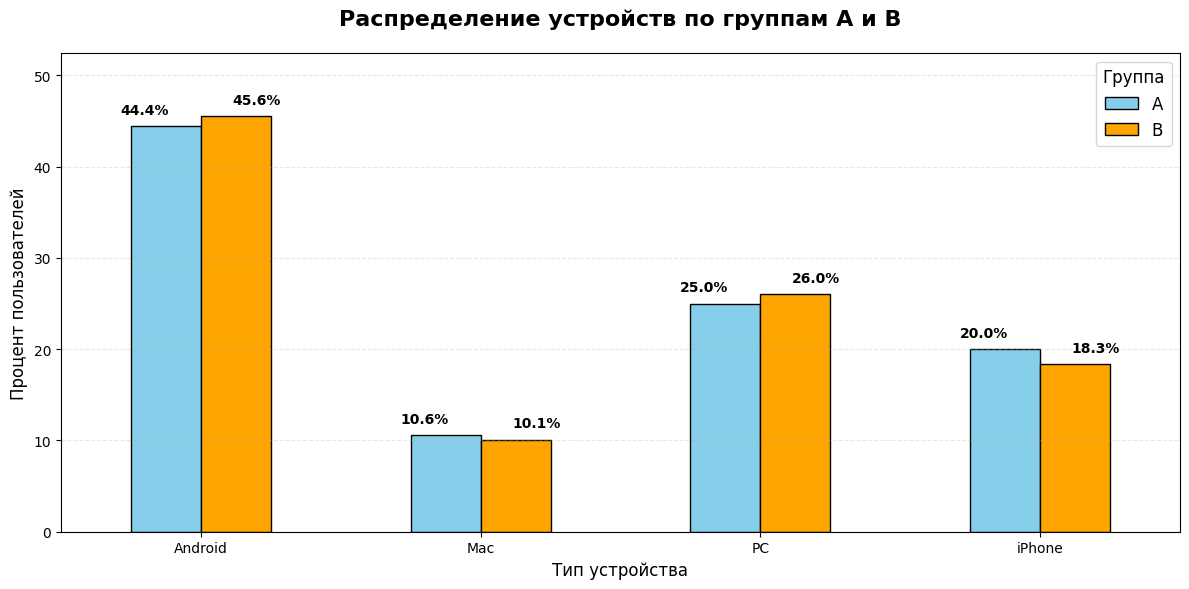

In [53]:
# Группируем данные по test_group и device, считаем количество уникальных user_id
device_distribution = (sessions_test_part
                       .groupby(['test_group', 'device'])['user_id']
                       .nunique()
                       .reset_index(name='count'))

# Рассчитываем доли устройств для каждой группы
device_distribution['percentage'] = (device_distribution.groupby('test_group')['count']
                                     .transform(lambda x: x / x.sum() * 100))

display(device_distribution)

# Построение столбчатой диаграммы
plt.figure(figsize=(12, 6))

# Используем pivot для удобства отображения данных
pivot_table = device_distribution.pivot(index='device', columns='test_group', values='percentage')

# Строим диаграмму
ax = pivot_table.plot(kind='bar', figsize=(12, 6), color=['skyblue', 'orange'], edgecolor='black')

# Добавляем значения на столбцы
for i, (device, row) in enumerate(pivot_table.iterrows()):
    for j, group in enumerate(pivot_table.columns):
        value = row[group]
        if not pd.isna(value):
            ax.text(i - 0.2 + j * 0.4,  # X-позиция
                    value + 1,           # Y-позиция немного выше столбца
                    f'{value:.1f}%',     # Форматируем с одним знаком после запятой
                    ha='center',
                    va='bottom',
                    fontsize=10,
                    fontweight='bold')

# Настройка графика
plt.title('Распределение устройств по группам A и B', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Тип устройства', fontsize=12)
plt.ylabel('Процент пользователей', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Группа', fontsize=12, title_fontsize=12)
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Устанавливаем пределы оси Y для лучшего отображения
plt.ylim(0, pivot_table.max().max() * 1.15)

# Автоматически настраиваем отступы
plt.tight_layout()

# Отображение графика
plt.show()

#### 3.4. Равномерность распределения пользователей по регионам
Теперь убедимся, что пользователи равномерно распределены по регионам.


,test_group,region,count,percentage
0,A,CIS,644,43.601896
1,A,EU,224,15.165877
2,A,MENA,609,41.232227
3,B,CIS,645,43.997271
4,B,EU,217,14.802183
5,B,MENA,604,41.200546


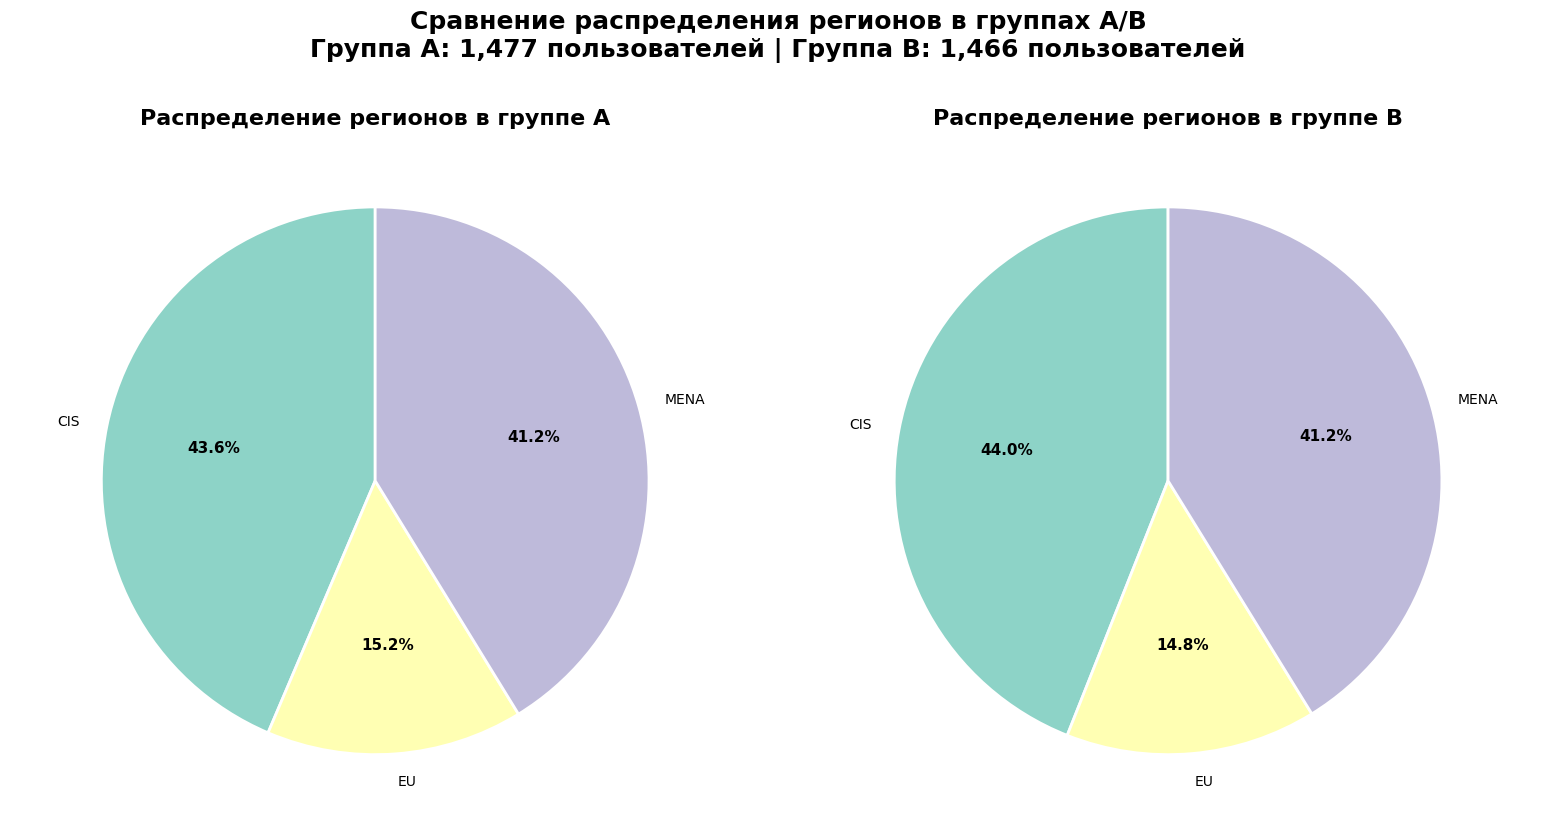

In [55]:
# Группируем данные по test_group и region, считаем количество уникальных user_id
region_distribution = (sessions_test_part
                       .groupby(['test_group', 'region'])['user_id']
                       .nunique()
                       .reset_index(name='count'))

# Рассчитываем доли регионов для каждой группы
region_distribution['percentage'] = (region_distribution.groupby('test_group')['count']
                                     .transform(lambda x: x / x.sum() * 100))

display(region_distribution)

# Разделяем данные на группы A и B
region_A = region_distribution[region_distribution['test_group'] == 'A']
region_B = region_distribution[region_distribution['test_group'] == 'B']

# Построение Круговых диаграмм для каждой группы
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Диаграмма для группы A
wedges_A, texts_A, autotexts_A = axes[0].pie(
    region_A['percentage'],
    labels=region_A['region'],
    autopct='%1.1f%%',
    startangle=90,
    colors=plt.cm.Set3.colors,  # Более яркая цветовая палитра
    textprops={'fontsize': 10},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2})  # Добавляем белые границы

# Улучшаем отображение процентов
for autotext in autotexts_A:
    autotext.set_color('black')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(11)

axes[0].set_title('Распределение регионов в группе A', fontsize=16, fontweight='bold', pad=20)
axes[0].axis('equal')  # Делаем круг идеально круглым

# Диаграмма для группы B
wedges_B, texts_B, autotexts_B = axes[1].pie(
    region_B['percentage'],
    labels=region_B['region'],
    autopct='%1.1f%%',
    startangle=90,
    colors=plt.cm.Set3.colors,
    textprops={'fontsize': 10},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2})

# Улучшаем отображение процентов
for autotext in autotexts_B:
    autotext.set_color('black')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(11)

axes[1].set_title('Распределение регионов в группе B', fontsize=16, fontweight='bold', pad=20)
axes[1].axis('equal')

# Добавляем общую легенду с количеством пользователей
total_A = region_A['count'].sum()
total_B = region_B['count'].sum()

fig.suptitle(f'Сравнение распределения регионов в группах A/B\n'
             f'Группа A: {total_A:,} пользователей | Группа B: {total_B:,} пользователей',
             fontsize=18, fontweight='bold', y=1.02)

# Автоматически настраиваем отступы
plt.tight_layout()

# Отображение графиков
plt.show()



Обязательно стоит проверять равномерность распределения, даже если в целом группы получились почти 50/50 по пользователям.

Проверка равномерности по количеству пользователей в группах — это один срез, но распределение по устройствам/регионам — это уже другие факторы, которые могут повлиять на поведение пользователей.

Например, пользователи Android и iOS могут по-разному конвертировать или тратить деньги.

Даже при идеально ровном делении пользователей (50/50) может оказаться, что в одной группе больше пользователей с iPhone, а в другой — с Android.



#### 3.5. Вывод после проверки A/B-теста


Различие в количестве пользователей в двух группах:
- Количество уникальных пользователей в группах A и B различается на 0.74%, что является незначительным отклонением.

Независимость выборок:
- Результат показал, что пересечений нет, каждый пользователь принадлежит только к одной группе A или B. Это подтверждает независимость выборок, что является важным условием корректности A/B-теста.

Распределение пользователей по устройствам:
- Распределение пользователей по типам устройств между группами A и B оказалось равномерным. Доли каждого типа устройств в обеих группах практически совпадают.
    Android: группа A — 44.41%, группа B — 45.57%.
    iPhone: группа A — 20.04%, группа B — 18.35%.
Различия в долях минимальны и не влияют на корректность теста.

Распределение пользователей по регионам:
- Распределение пользователей по регионам также оказалось равномерным. Доли пользователей из каждого региона в группах A и B практически одинаковы.
    CIS: группа A — 43.60%, группа B — 43.99%.
    MENA: группа A — 41.23%, группа B — 41.20%.
Различия в долях минимальны и не влияют на корректность теста.

Соответствие размера выборки и длительности теста:
- Необходимый размер выборки для каждой группы был рассчитан как 17441 пользователь. За один день удалось набрать около 1477+1466=2943 уникальных пользователей. Это составляет примерно 17% от необходимого размера выборки: 2943/17441=0,17. Если трафик останется стабильным, за 4 дня можно ожидать набор достаточного количества данных для анализа.

Заключение о корректности A/B-теста:
- На основе проведённого анализа можно сделать вывод, что A/B-тест проходит корректно.

### 4. Проверка результатов A/B-теста


#### 4.1. Получение результатов теста и подсчёт основной метрики


In [56]:
uploaded = files.upload()

for filename in uploaded.keys():
    sessions_test  = pd.read_csv(io.BytesIO(uploaded[filename]))
    break

Saving sessions_project_test (1).csv to sessions_project_test (1).csv


In [57]:
# Создаём дополнительный столбец good_session
sessions_test['good_session'] = (sessions_test['page_counter'] >= 4).astype(int)

# Выводим первые строки датафрейма для проверки
display(sessions_test.head(10))

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_group,good_session
0,6DAE3B3654DA738E,C69249E26E58F6E2,2025-10-26,2025-10-26 18:15:05,2025-10-16,3,0,3,MENA,Android,A,0
1,0A3FE5D1DD59110A,66D66D7C9F5181B7,2025-10-21,2025-10-21 17:04:53,2025-10-15,2,1,2,CIS,Android,B,0
2,2041F1D7AA740B88,50DE51D42215E74C,2025-10-23,2025-10-23 17:39:29,2025-10-19,3,0,2,MENA,Android,A,0
3,43D7585009168086,5763C0C353C22263,2025-10-24,2025-10-24 15:01:57,2025-10-18,4,0,1,CIS,iPhone,B,0
4,15AD68B14D62D88C,B1AD09F93C1053BC,2025-10-17,2025-10-17 17:34:39,2025-10-17,1,0,2,MENA,Android,B,0
5,31F7A42B32103403,E9B64B779C3348ED,2025-10-20,2025-10-20 17:09:41,2025-10-19,2,0,2,CIS,PC,B,0
6,87C09E3E3B334959,FECFF83C13DC9364,2025-10-22,2025-10-22 23:51:42,2025-10-20,3,0,4,CIS,iPhone,B,1
7,457F2674E87EF6E7,14F71C18BE2CEC08,2025-10-19,2025-10-19 11:49:11,2025-10-19,1,0,3,MENA,Mac,A,0
8,57F342451921D207,76EFA055599ADE3C,2025-10-19,2025-10-19 18:47:43,2025-10-19,1,0,3,CIS,PC,A,0
9,3404844B53442747,B4901323BD537E45,2025-10-14,2025-10-14 19:28:49,2025-10-14,1,0,3,CIS,Android,B,0


#### 4.2. Проверка корректности результатов теста

Необходимо убедиться, что тест проведён корректно и вы будете сравнивать две сопоставимые группы.

- Рассчитаем количество уникальных сессий для каждого дня и обеих тестовых групп, используя группировку.

- Проверим, что количество уникальных дневных сессий в двух выборках не различается или различия не статистически значимы. Используем статистический тест, который позволит сделать вывод о равенстве средних двух выборок.



In [58]:
# Группируем данные по session_date и test_group, считаем количество уникальных сессий
daily_sessions_by_group = (sessions_test.groupby(['session_date', 'test_group'])
                                                 ['session_id'].nunique().reset_index(name='unique_sessions'))

# Выводим результат
display(daily_sessions_by_group)

,session_date,test_group,unique_sessions
0,2025-10-14,A,1502
1,2025-10-14,B,1628
2,2025-10-15,A,2235
3,2025-10-15,B,2283
4,2025-10-16,A,3280
5,2025-10-16,B,3241
6,2025-10-17,A,4089
7,2025-10-17,B,4054
8,2025-10-18,A,5013
9,2025-10-18,B,5059


Гипотезы для анализа количества уникальных дневных сессий:
- Нулевая гипотеза (H₀): Количество уникальных дневных сессий в тестовой (B) и контрольной (A) группах не различается.
- Альтернативная гипотеза (H₁): Количество уникальных дневных сессий в тестовой (B) и контрольной (A) группах различается.

In [59]:
# Разделяем данные на две группы
group_A = daily_sessions_by_group[daily_sessions_by_group['test_group'] == 'A']['unique_sessions']
group_B = daily_sessions_by_group[daily_sessions_by_group['test_group'] == 'B']['unique_sessions']

# Проводим t-тест для сравнения средних
t_stat, p_value = ttest_ind(group_A, group_B)

# Выводим результат
display(f"p-value: {p_value:.4f}")

# Интерпретация p-value
if p_value < 0.05:
    display("Нулевая гипотеза не находит подтверждение")
else:
    display("Нулевая гипотеза находит подтверждение")


'p-value: 0.9382'

'Нулевая гипотеза находит подтверждение'

#### 4.3. Сравнение доли успешных сессий

Используем созданный на первом шаге задания столбец `good_session` и рассчитаем долю успешных сессий для выборок A и B, а также разницу в этом показателе.

In [60]:
# Группируем данные по test_group и рассчитываем долю успешных сессий
success_rate_by_group = (sessions_test.groupby('test_group')['good_session'].mean().reset_index(name='success_rate'))

# Добавляем столбец с процентным форматом для удобства
success_rate_by_group['success_rate_percent'] = success_rate_by_group['success_rate'] * 100

# Находим разницу в долях успешных сессий между группами
success_rate_A = success_rate_by_group.loc[success_rate_by_group['test_group'] == 'A', 'success_rate'].values[0]
success_rate_B = success_rate_by_group.loc[success_rate_by_group['test_group'] == 'B', 'success_rate'].values[0]
difference = success_rate_B - success_rate_A

# Выводим результаты
display("Доля успешных сессий:")
display(success_rate_by_group)
display(f"\nРазница в долях успешных сессий между группами (B - A): {difference:.4f} (или {difference * 100:.2f}%)")

'Доля успешных сессий:'

,test_group,success_rate,success_rate_percent
0,A,0.307723,30.772336
1,B,0.318290,31.828993


'\nРазница в долях успешных сессий между группами (B - A): 0.0106 (или 1.06%)'

 Сравнение доли успешных сессий — важный шаг, потому что именно эта метрика показывает, насколько эффективно пользователи достигают целевого действия при взаимодействии с продуктом.

Если доля успешных сессий в одной из групп выше, это может говорить о том, что изменения, протестированные в этой группе, положительно повлияли на пользовательский опыт. А значит, они могут быть внедрены в основную версию продукта.

Без такой проверки невозможно оценить реальное влияние нововведения — даже если распределение сессий по группам было корректным.


#### 4.4. Насколько статистически значимо изменение ключевой метрики

- Используя статистический тест, рассчитаем, является ли изменение в метрике доли успешных сессий статистически значимым.



Гипотезы для анализа доли успешных сессий:
- Нулевая гипотеза (H₀): Доля успешных сессий в тестовой (B) и контрольной (A) группах не различается.
- Альтернативная гипотеза (H₁): Доля успешных сессий в тестовой (B) и контрольной (A) группах различается.

In [61]:
# Количество успешных сессий и общее количество сессий в каждой группе
successes_A = sessions_test[sessions_test['test_group'] == 'A']['good_session'].sum()
total_A = sessions_test[sessions_test['test_group'] == 'A'].shape[0]
successes_B = sessions_test[sessions_test['test_group'] == 'B']['good_session'].sum()
total_B = sessions_test[sessions_test['test_group'] == 'B'].shape[0]

# Z-тест для пропорций
count = [successes_A, successes_B]  # Количество успешных сессий в группах
nobs = [total_A, total_B]          # Общее количество сессий в группах
z_stat, p_value = proportions_ztest(count, nobs)

# Вывод результатов
display(f"p-value: {p_value:.4}")
if p_value < 0.05:
    display("Нулевая гипотеза не находит подтверждение")
else:
    display("Нулевая гипотеза находит подтверждение")

'p-value: 0.0003149'

'Нулевая гипотеза не находит подтверждение'

#### 4.5. Вывод по результатам A/B-эксперимента



1. Количество задействованных пользователей:

    - Группа A: 1477 уникальных пользователей
    - Группа B: 1466 уникальных пользователей.
    - Общее количество пользователей: 2943.
    - Длительность эксперимента: Тест длился 3 дня при уровне трафика в 9907 уникальных пользователей в день.
    - Необходимый размер выборки для каждой группы: 17441 пользователь, рассчитанная длительность теста: 4 дня.
    

2. Влияние нового алгоритма рекомендаций на ключевую метрику:
    
    Ключевой метрикой является доля успешных сессий good_session, где успешной считается сессия с просмотром 4 и более страниц.
   Доля успешных сессий:
   - Группа A (контрольная): 30.77%
   - Группа B (тестовая): 31.83%
   - Разница между группами: +1.06% (группа B показала улучшение).
   
   
3. Статистическая значимость выявленного эффекта:
   
   Для оценки статистической значимости разницы в долях успешных сессий был использован z-тест для пропорций.
     Полученное значение p-value: 0.0003, уровень значимости α был установлен на уровне 0.05.Так как p-value < 0.05, мы можем      отвергнуть нулевую гипотезу. Следовательно наблюдаемая разница в 1.06%  является статистически значимой и является  реальным эффектом нового алгоритма.
     
     
4. Рекомендации по внедрению нововведения:
   
   На основе анализа можно сделать вывод, что новый алгоритм рекомендаций продемонстрировал статистически значимое влияния на ключевую метрику (долю успешных сессий). Есть необходимость внедрить новый алгоритм рекомендаций в текущем виде, так как он  оказывает положительный эффект на пользовательскую активность.